In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#replacing blanks with 0 as tenure is 0 and no total charges are recorded 

In [3]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df["customerID"].duplicated().sum()

np.int64(0)

In [8]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

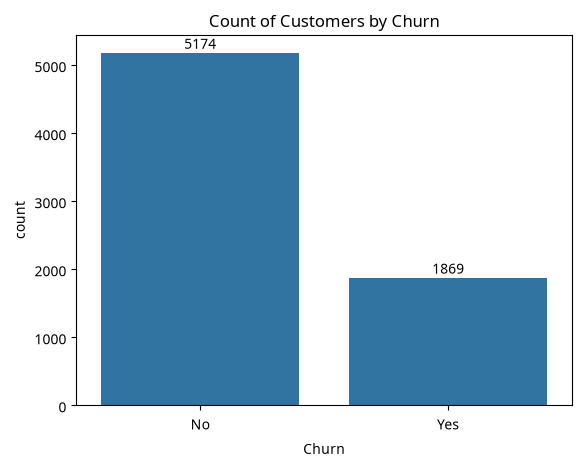

In [9]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

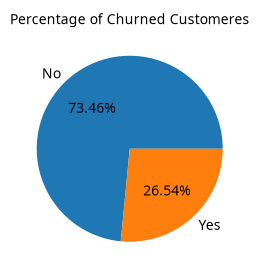

In [10]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out. 
#not let's explore the reason behind it

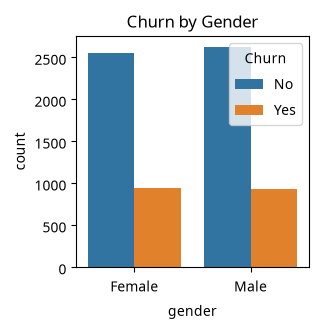

In [11]:
plt.figure(figsize = (3,3))
sns.countplot(x = "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.show()

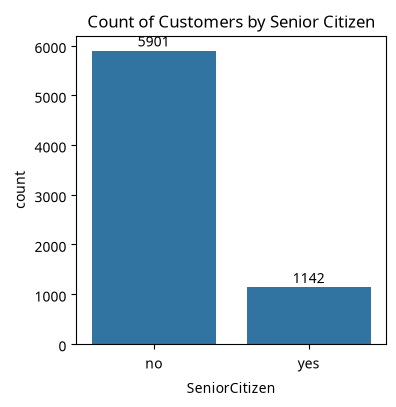

In [12]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen")
plt.show()

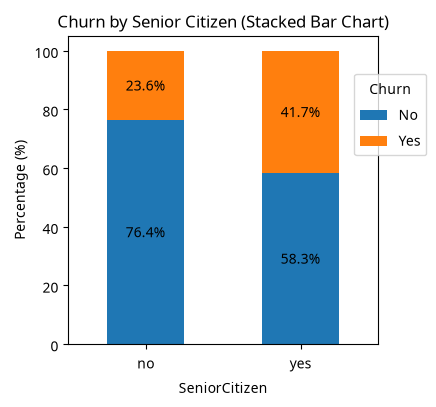

In [13]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 4))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))  # Customize legend location

plt.show()

#comparative a greater pecentage of people in senior citizen category have churned

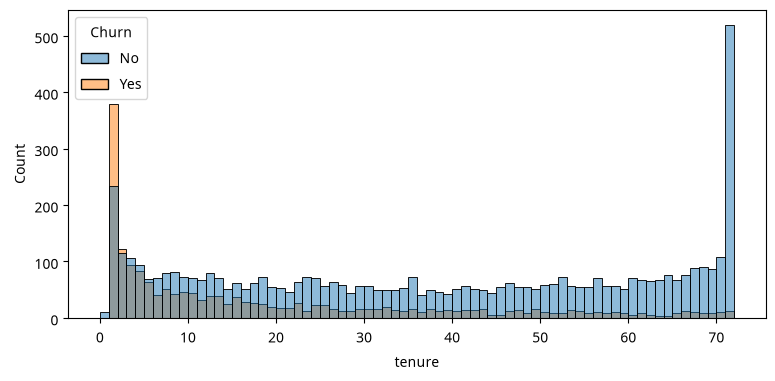

In [14]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our sevices 
#1 or 2 months  have churned

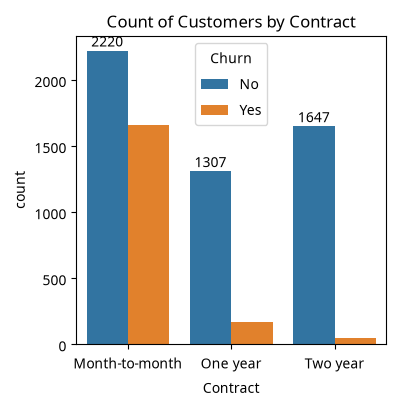

In [15]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

In [16]:
#people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract. 

In [17]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

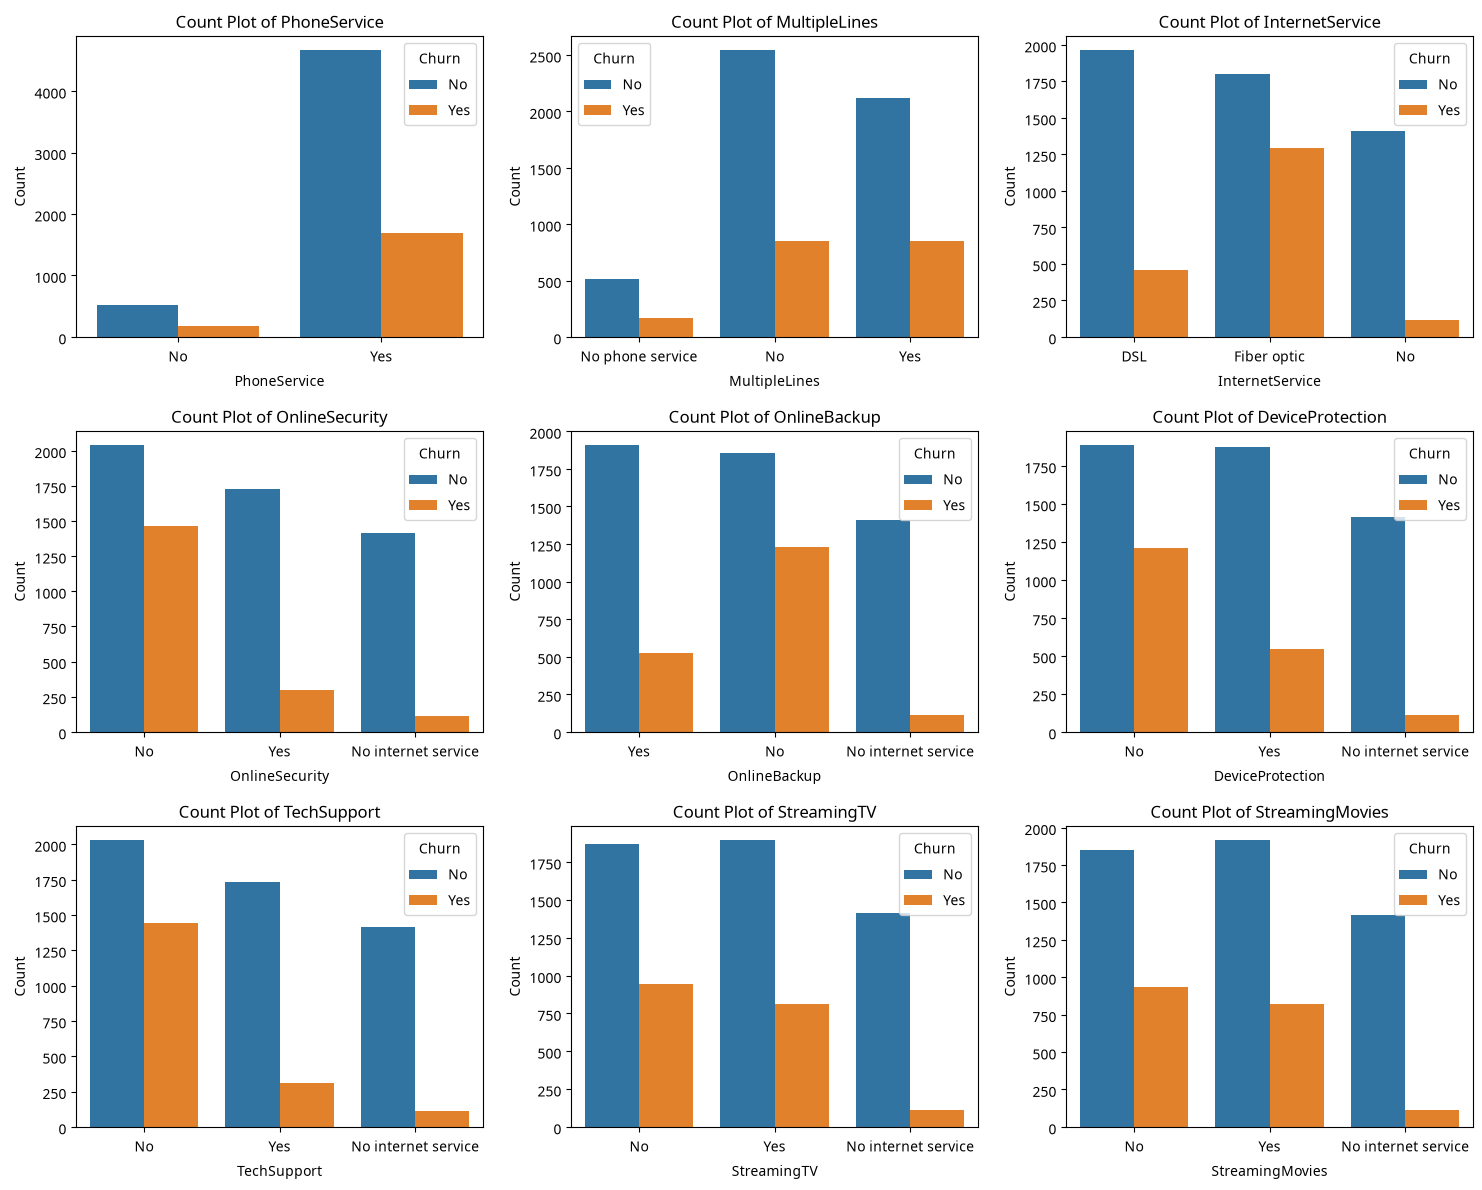

In [18]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns for the subplot grid (you can change this)
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))  # Adjust figsize as needed

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable. 

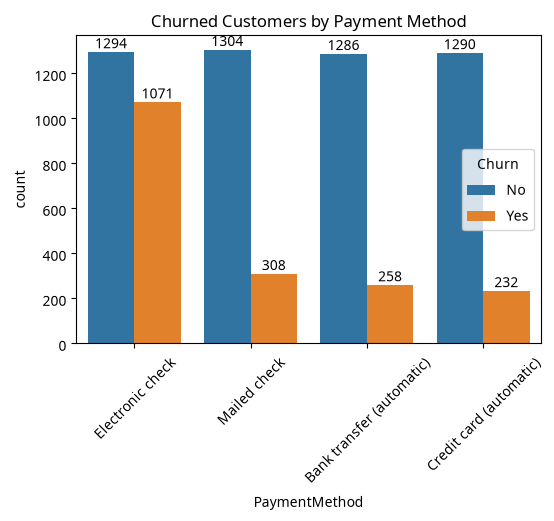

In [19]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method. 

## Machine Learning: Predicting Churn
Goal: predict whether a customer will churn (Yes/No). I will train 5 models one by one, check the accuracy of each, and then pick the best.

In [20]:
# Step 1: prepare data for ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = df.drop(columns=["customerID"])          # id is not useful for prediction
y = data["Churn"].map({"Yes": 1, "No": 0})      # target: 1 = churned, 0 = stayed
X = pd.get_dummies(data.drop(columns=["Churn"]), drop_first=True)   # text columns -> numbers

# 80% train, 20% test (stratify keeps the same churn % in both)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# scaling (needed for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (5634, 30) | Test size: (1409, 30)


### Model 0: Baseline (just to compare)
A dumb model that says 'No churn' for everyone. Any real model must beat this.

In [21]:
from sklearn.metrics import accuracy_score

baseline_acc = 1 - y_test.mean()     # accuracy if we predict "No" for all customers
print("Baseline accuracy:", round(baseline_acc, 4))

Baseline accuracy: 0.7346


### Model 1: Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))
print("Logistic Regression accuracy:", round(lr_acc, 4))

Logistic Regression accuracy: 0.807


### Model 2: Decision Tree
I limit `max_depth` to 5, otherwise the tree memorizes the training data (overfitting).

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print("Decision Tree train accuracy:", round(accuracy_score(y_train, dt.predict(X_train)), 4))
print("Decision Tree test accuracy :", round(dt_acc, 4))

Decision Tree train accuracy: 0.8023
Decision Tree test accuracy : 0.7942


### Model 3: Random Forest
Many decision trees voting together.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print("Random Forest accuracy:", round(rf_acc, 4))

Random Forest accuracy: 0.8062


### Model 4: KNN
Predicts using the 5 most similar customers.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_sc))
print("KNN accuracy:", round(knn_acc, 4))

KNN accuracy: 0.7473


### Comparing all models

                 Model  Accuracy
0  Logistic Regression    0.8070
1        Random Forest    0.8062
2        Decision Tree    0.7942
3                  KNN    0.7473
4    Baseline (all No)    0.7346


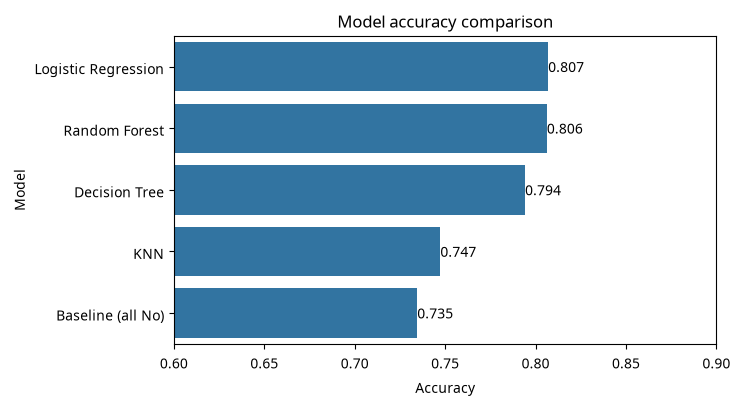

In [26]:
results = pd.DataFrame({
    "Model": ["Baseline (all No)", "Logistic Regression", "Decision Tree", "Random Forest", "KNN"],
    "Accuracy": [baseline_acc, lr_acc, dt_acc, rf_acc, knn_acc]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(results.round(4))

plt.figure(figsize=(7, 4))
ax = sns.barplot(x="Accuracy", y="Model", data=results)
ax.bar_label(ax.containers[0], fmt="%.3f")
plt.title("Model accuracy comparison")
plt.xlim(0.6, 0.9)
plt.show()

### Accuracy alone can fool us
Only ~26% customers churn, so the baseline already gets ~73% accuracy. What we really care about is **recall for churn**: out of all customers who actually churned, how many did the model catch? Let's check that for every model.

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

preds = {
    "Logistic Regression": lr.predict(X_test_sc),
    "Decision Tree": dt.predict(X_test),
    "Random Forest": rf.predict(X_test),
    "KNN": knn.predict(X_test_sc),
}
rows = []
for name, p in preds.items():
    rows.append([name, accuracy_score(y_test, p), precision_score(y_test, p),
                 recall_score(y_test, p), f1_score(y_test, p)])
compare = pd.DataFrame(rows, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
compare.round(3)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.807,0.658,0.567,0.609
1,Decision Tree,0.794,0.631,0.540,0.582
2,Random Forest,0.806,0.684,0.503,0.579
3,KNN,0.747,0.525,0.500,0.512


Best model (by F1): Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



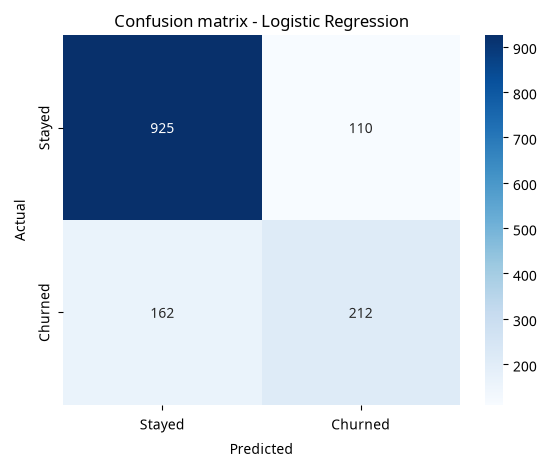

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

best_name = compare.sort_values("F1", ascending=False).iloc[0]["Model"]   # best balance of precision and recall
print("Best model (by F1):", best_name)
best_pred = preds[best_name]

print(classification_report(y_test, best_pred, target_names=["Stayed", "Churned"]))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion matrix - {best_name}")
plt.show()

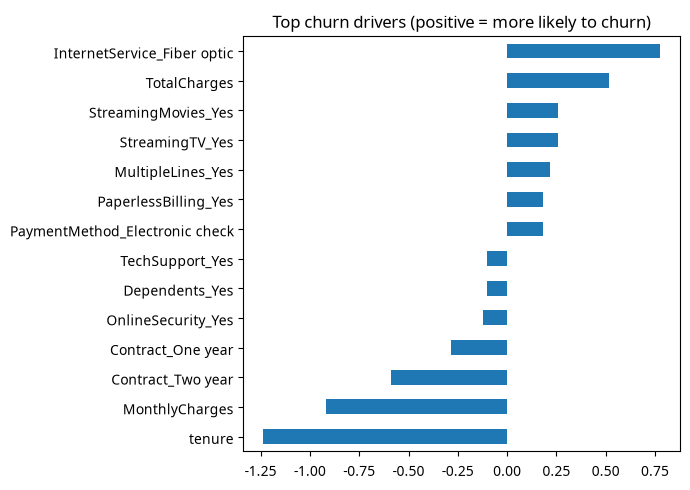

In [29]:
# What makes customers churn? (Logistic Regression coefficients)
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
pd.concat([coef.head(7), coef.tail(7)]).plot(kind="barh", figsize=(7, 5),
    title="Top churn drivers (positive = more likely to churn)")
plt.tight_layout()
plt.show()

### Conclusion
(write here after running: which model had the best accuracy, which had the best recall, how much better than baseline, and the top 3 churn drivers)

In [30]:
# Accuracy comparison table
accuracy_comparison = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
accuracy_comparison


,Model,Accuracy
0,Logistic Regression,0.806955
1,Random Forest,0.806246
2,Decision Tree,0.794180
3,KNN,0.747339
4,Baseline (all No),0.734564


In [31]:
# Recall and F1 comparison table
recall_f1_comparison = compare[["Model", "Recall", "F1"]].copy()
recall_f1_comparison.round(3)


,Model,Recall,F1
0,Logistic Regression,0.567,0.609
1,Decision Tree,0.540,0.582
2,Random Forest,0.503,0.579
3,KNN,0.500,0.512
